In [2]:
import scipy
import sys
from skimage import io
import numpy as np
import numpy.matlib
import matplotlib
import skimage
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import pandas as pd
from numpy import matlib
import seaborn as sns
import math
import os
import scipy.optimize
import scipy.io as sio
from scipy import stats
import scipy.ndimage
from scipy.interpolate import make_smoothing_spline

sns.set(font_scale=1.5)
sns.set_style("whitegrid")

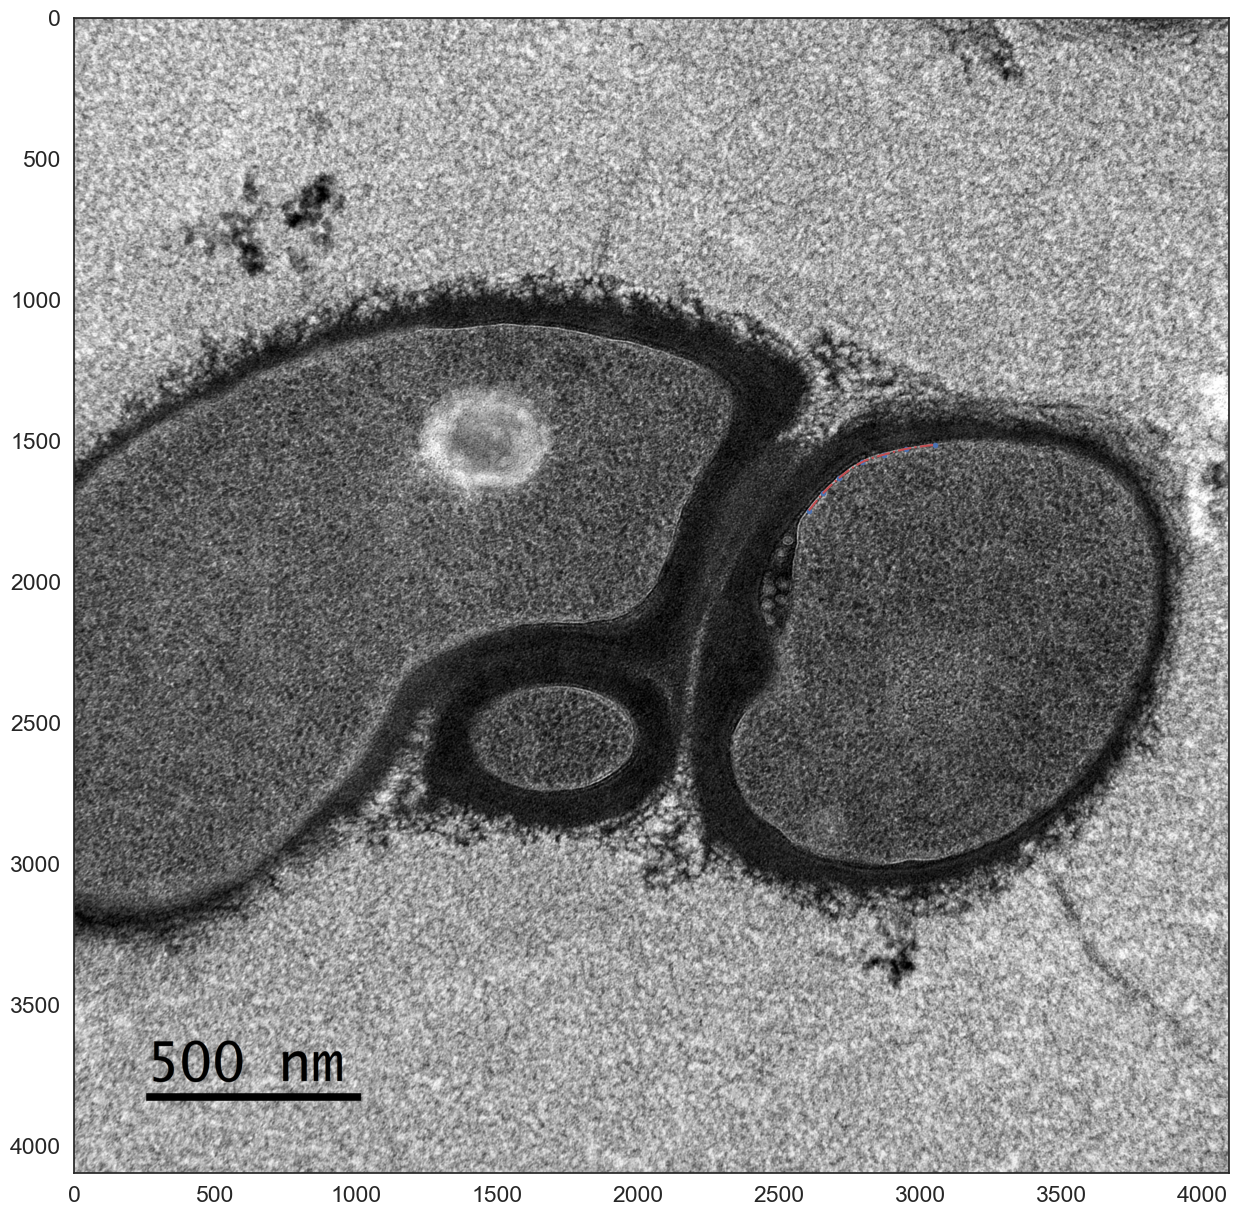

In [3]:
base_path="/Volumes/data_ssd3/Barber_Lab/data"
expt_id="/20260602_TEM_HPF"
cond="/ponA_mg_A3805"
im="ponA_mg_10kX_0004"
im1=io.imread(base_path+expt_id+cond+'/'+im+'.tif')

coords=pd.read_csv(base_path+expt_id+'/trace'+cond+'/'+im+'/'+im+'_cell_1.csv')
xv,yv=np.asarray(coords.X),np.asarray(coords.Y)
sns.set_style('white')
fig=plt.figure(figsize=[15,15])
plt.imshow(im1)
plt.plot(xv,yv,'.')
lam=10
spl = make_smoothing_spline(xv[np.argsort(xv)], yv[np.argsort(xv)], lam=lam)
xnew = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/100)
plt.plot(xnew, spl(xnew), '-.', label=fr'$\lambda=${lam}',color='r')

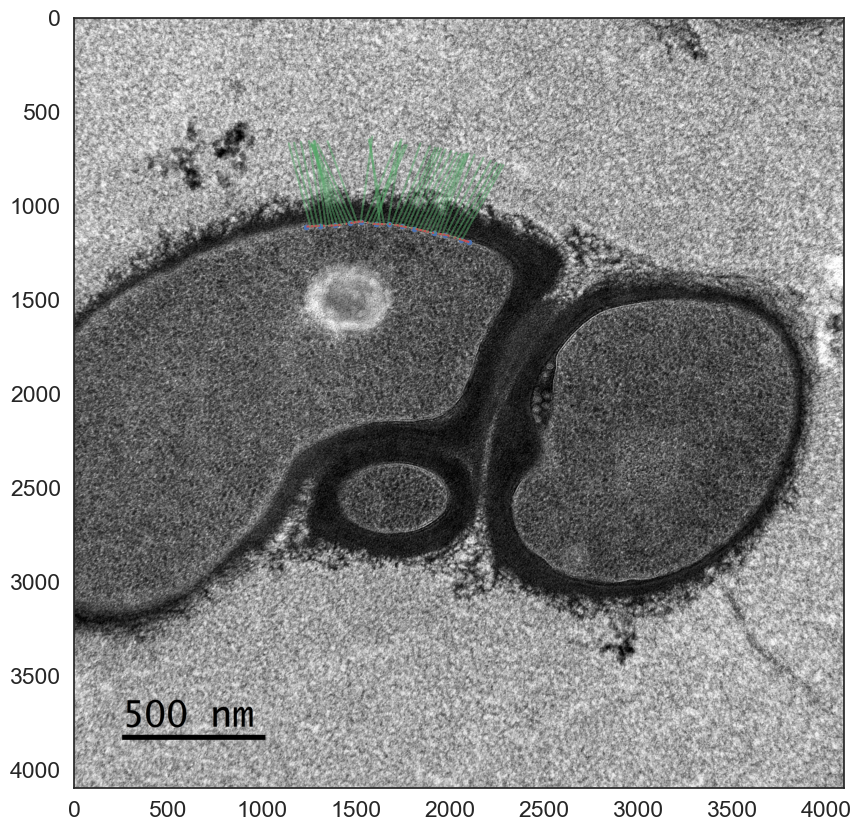

In [9]:
conds=["/ponA_mg_A3805"]
cond_seg_name=['/ponA_mg']
cond_ind=0
cond=conds[cond_ind]
im3=io.imread(base_path+expt_id+'/segment'+cond_seg_name[cond_ind]+'_bg_cell'+cond_seg_name[cond_ind]+'_10kX_0004_seg.tif')

coords=pd.read_csv(base_path+expt_id+'/trace'+cond+'/'+im+'/'+im+'_cell_3.csv')
xv,yv=np.asarray(coords.X),np.asarray(coords.Y)
sns.set_style('white')
fig=plt.figure(figsize=[10,10])
plt.imshow(im1)
plt.plot(xv,yv,'.')
lam=10
spl = make_smoothing_spline(xv[np.argsort(xv)], yv[np.argsort(xv)], lam=lam)
num_fits=40
xnew = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/(num_fits+2))[1:-1]
xnew1 = np.arange(np.amin(xv), np.amax(xv), np.absolute(np.amax(xv)-np.amin(xv))/1000)
ynew1=spl(xnew1)
plt.plot(xnew1, spl(xnew1), '-.', label=fr'$\lambda=${lam}',color='r')
window=10
scale=500.0/762.0 # nm/pixel.
depth=300
opp_depth=int(0/scale) # distance in nm to backtrack — allows you to precisely measure the position of the membrane
intensity_vals=np.nan*np.ones([len(xnew),int(depth/scale)+opp_depth])
im_intensity_vals=np.nan*np.ones([len(xnew),int(depth/scale)+opp_depth])
im2=im1[:,:,0]
min_depth=100 # minimum depth for us to consider a cross-section for analysis
cutoff_length=int(opp_depth+min_depth/scale)


for ind in np.arange(len(xnew)):
    point=np.nonzero(xnew1>xnew[ind])[0][0]
    slope=scipy.stats.linregress(xnew1[point-window:point+window],ynew1[point-window:point+window])
    num_points=int(np.absolute(slope[0]*depth/scale)) # number of x values to change in order to get that amount of y change
    xs=np.sign(xv[-1]-xv[0])*np.sign(slope[0]) # determines whether x should increase or decrease.
    xrange=np.arange(xnew[ind],xnew[ind]-num_points,-1)
    yrange=float(spl(xnew1[point]))-1.0/slope[0]*(xrange-xnew1[point])
    # now let's unit-spaced coordinates along this line, from start to end.
    dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slope[0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slope[0]))
    xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
    sel_vals=np.nonzero((xcoords>=0)*(xcoords<=im1.shape[1])*(ycoords>=0)*(ycoords<=im1.shape[0]))
    if len(sel_vals[0])>cutoff_length:
        plt.plot(xcoords[sel_vals],ycoords[sel_vals],'-',color='g',alpha=0.5)
        intensity_vals[ind,sel_vals]=im3[xcoords[sel_vals].astype(int),ycoords[sel_vals].astype(int)]
        im_intensity_vals[ind,sel_vals]=im2[xcoords[sel_vals].astype(int),ycoords[sel_vals].astype(int)]

# intensity_vals1=intensity_vals[np.nonzero(np.sum(np.isnan(intensity_vals),axis=1)!=intensity_vals.shape[1])[0],:]

In [10]:
final_inds=[]
offset_ind=int(0/scale)
cutoff=0.2
bkgd=(255.0-170.0)/255.0
final_inds=[]
for temp_int in range(intensity_vals.shape[0]):
    if np.sum(np.isnan(intensity_vals[temp_int,:]))<intensity_vals.shape[1]: # if this is not totally outside the image in 
        # question
        signal=intensity_vals[temp_int,offset_ind:]

        if np.sum(signal>0)>0: # if we reach background segmentation then we accept that first intercept here. Otherwise we take len(signal)
            final_inds.append(np.nonzero(signal>0)[0][0]+offset_ind)
        elif np.sum(np.isnan(intensity_vals[temp_int,:]))==0:
            final_inds.append(len(signal)-1)
        else:
            final_inds.append(np.nonzero(np.isnan(signal))[0][0])
    else:
        final_inds.append(np.nan)
        
        # temp_peaks=scipy.signal.find_peaks(signal,width=2)
        # temp_proms=scipy.signal.peak_prominences(signal, temp_peaks[0], wlen=None)
        # temp_peaks1=np.asarray(temp_peaks[0])[np.nonzero(temp_proms[0]>cutoff)]
        # temp_vals=signal[temp_peaks1]>0.5*np.nanmax(signal)
        # if np.sum(temp_vals)>0:
        #     final_inds.append(temp_peaks1[np.nonzero(temp_vals)[0][0]]+offset_ind)
        # else:
        #     final_inds.append(np.nan)
    # else:
    #     final_inds.append(np.nan)

Okay, that should have saved the end of each piece of cell wall. Let's check.

Text(0, 0.5, 'Cell wall intensity')

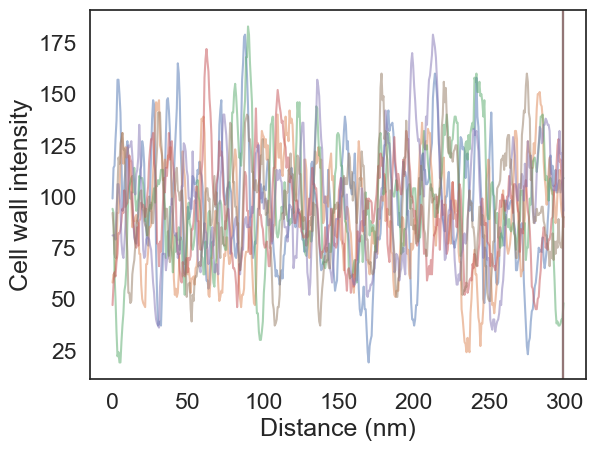

In [12]:
ints=np.random.randint(low=0,high=intensity_vals.shape[0]-1,size=6)
fig=plt.figure()
temp_xv=scale*np.arange(intensity_vals.shape[1])
for i0 in range(len(ints)):
    if np.sum(np.isnan(intensity_vals[ints[i0],:]))<intensity_vals.shape[1]:
        # lines=plt.plot(x,skimage.filters.gaussian(intensity_vals[int_temp,:],sigma=1),alpha=1.0)
        lines=plt.plot(temp_xv,im_intensity_vals[ints[i0],:],alpha=0.5)
        plt.axvline(scale*(final_inds[ints[i0]]),color=lines[0].get_color(),alpha=0.5)
# plt.axvline(0,color='k')
# background=(255.0-np.mean(im2[:1000,:1000].flatten()))/255.0
# plt.axhline(background)
plt.xlabel('Distance (nm)')
plt.ylabel('Cell wall intensity')

Looks pretty good to me!! Let's visualize this.

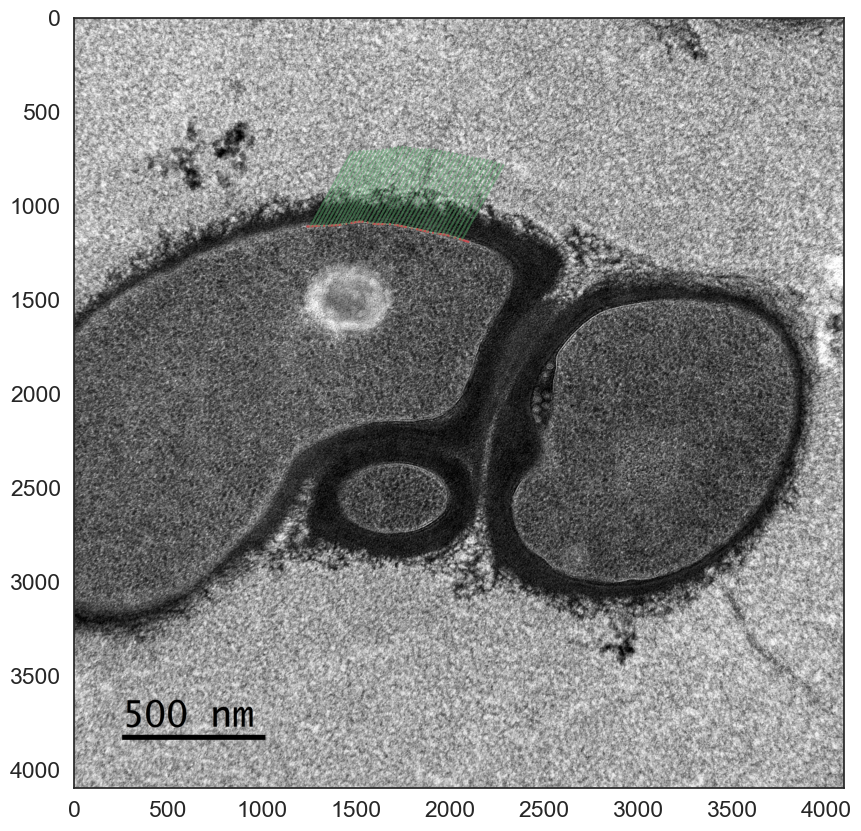

In [13]:

sns.set_style('white')
fig=plt.figure(figsize=[10,10])
plt.imshow(im1)

plt.plot(xnew1, spl(xnew1), '-.', label=fr'$\lambda=${lam}',color='r')
for ind in np.arange(len(xnew)):
    if ~np.isnan(final_inds[ind]):
        xs=np.sign(xv[-1]-xv[0])*np.sign(slope[0]) # determines whether x should increase or decrease.
        yrange=float(spl(xnew1[point]))-1.0/slope[0]*(xrange-xnew1[point])
        # now let's unit-spaced coordinates along this line, from start to end.
        dx,dy=np.sign(xs)/np.sqrt(1+np.absolute(1.0/slope[0])),np.sign(-xv[-1]+xv[0])/np.sqrt(1+np.absolute(slope[0]))
        xcoords,ycoords=xnew[ind]+dx*np.arange(-opp_depth,int(depth/scale)),float(spl(xnew[ind]))+dy*np.arange(-opp_depth,int(depth/scale))
        temp_xcoords=[xcoords[opp_depth],xcoords[final_inds[ind]]]
        temp_ycoords=[ycoords[opp_depth],ycoords[final_inds[ind]]]
        plt.plot(temp_xcoords,temp_ycoords,'-',color='g',alpha=0.5)

This I think is looking okay. Now, let's calculate an average for this cell and figure out how to scale this for all images across all samples.